Centrality Differences Across Teaching and Non-Teaching Hospitals

DATA 620 – Project 1

Woodelyne Durosier

03/09/2026

**Introduction**

Healthcare systems are made up of intricate regional networks of hospitals that communicate with one another through shared service regions and referral patterns. Knowing how these networks are organized can help identify which hospitals are essential to local healthcare systems.

In this project,  Health Service Areas (HSA) was use as the foundation for network connections to examine the network topology of US hospitals. Hospitals that are part of the same Health Service Area are linked via edges, with each hospital serving as a node in the network.

Two significant network centrality metrics are computed using this network:

**Degree Centrality** is a measure of how many connections a hospital has within the network.

**Eigenvector Centrality** assesses a hospital's influence based on the importance of its connections.

 These centrality were compare to measures across hospital types, which serve as the analysis' categorical variable.

In [2]:
# Import Libraries
#Python libraries are used for data manipulation, network analysis, statistical testing, and visualization.

import pandas as pd
import networkx as nx
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

**Load Dataset**

This project used the Dartmouth Atlas Hospital Dataset, which contains structural information about hospitals in the United States such as provider identifiers, hospital type classifications, and geographic service areas.

Each hospital is given a unique provider number (NEW_PROV) and assigned to a Health Service Area (HSA).

In [4]:


df= pd.read_csv("hosp17_atlas.csv")


**Inspect and Clean Data**

Initially, the dataset was examin and exclude any rows that lack hospital type information. The categorical variable used to compare centrality between groups will be hospital type.

In [5]:

df.columns
df = df.dropna(subset=['HOSPTYPE'])
df.head()

,PROVIDER,NEW_PROV,STATUS17,SHORTNAME,PNAME,PCITY,PSTATE,PZIP,HSA,HSANAME,...,FCNTYNAME,POSbeds,SYSNAME,AHAbeds,CATEGORY,TEACHSTATUS,HOSPTYPE,NCI_CENTER,EXCL_FLAG,ICU_FLAG
0,10001,010001,9.OK?,Southeast Alabama Medical Center,SOUTHEAST ALABAMA MEDICAL CENTER,DOTHAN,AL,36301,1026,AL- DOTHAN,...,AL-Houston County,408,NaN,387.0,NaN,NaN,4.Other acute care hosp,NaN,9.OK?,NaN
1,10005,010005,9.OK?,Marshall Medical Center South,MARSHALL MEDICAL CENTER SOUTH,BOAZ,AL,35957,1012,AL- BOAZ,...,AL-Marshall County,240,Marshall Health System,114.0,NaN,NaN,4.Other acute care hosp,NaN,9.OK?,NaN
2,10006,010006,9.OK?,Eliza Coffee Memorial Hospital,ELIZA COFFEE MEMORIAL HOSPITAL,FLORENCE,AL,35631,1036,AL- FLORENCE,...,AL-Lauderdale County,358,RCCH HealthCare Partners,278.0,NaN,NaN,4.Other acute care hosp,NaN,9.OK?,NaN
3,10007,010007,9.OK?,Mizell Memorial Hospital,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,1065,AL- OPP,...,AL-Covington County,85,NaN,59.0,NaN,NaN,4.Other acute care hosp,NaN,9.OK?,NaN
4,10008,010008,9.OK?,Crenshaw Community Hospital,CRENSHAW COMMUNITY HOSPITAL,LUVERNE,AL,36049,1056,AL- LUVERNE,...,AL-Crenshaw County,45,NaN,65.0,NaN,NaN,4.Other acute care hosp,NaN,9.OK?,noICUdays


**Network Construction**

To build a hospital network:

Nodes: Individual hospitals (NEW_PROV)

Edges: Hospitals linked if they belong to the same Health Service Area (HSA).

Hospitals in the same HSA share regional healthcare markets and patient catchment areas, resulting in a significant relational structure.

In [6]:

G = nx.Graph()

# add nodes
for hospital in df['NEW_PROV']:
    G.add_node(hospital)

# create edges by HSA
for hsa in df['HSA'].unique():

    hospitals = df[df['HSA']==hsa]['NEW_PROV'].tolist()

    for i in range(len(hospitals)):
        for j in range(i+1, len(hospitals)):
            G.add_edge(hospitals[i], hospitals[j])

In [7]:
# Network Size(Examin the size of the constructed network)
print(G.number_of_nodes())
print(G.number_of_edges())

5013
8582


**Nodes:** 5013 hospital

**Edges:** 8582 hospital connection

This indicate a moderately connected national hospital based on  shared service areas.

**Centrality Measures**

We compute two centrality measures for each hospital:

• Degree Centrality

• Eigenvector Centrality

In [8]:
degree = nx.degree_centrality(G)
eigen = nx.eigenvector_centrality(G, max_iter=1000)

**Merge Centrality with Dataset**

The calculated centrality values are then returned to the dataset.

In [9]:
df['degree_centrality'] = df['NEW_PROV'].map(degree)
df['eigenvector_centrality'] = df['NEW_PROV'].map(eigen)

**Compare Centrality Across Hospital Types**

Hospital type serves as the categorical variable for this analysis. We compute the average centrality values for each hospital category.

In [10]:
# compare Across the Hospital Types
df.groupby('HOSPTYPE')[['degree_centrality','eigenvector_centrality']].mean()

,degree_centrality,eigenvector_centrality
HOSPTYPE,,
1.Integrated AMC,0.001934,0.002239
2.Other teaching hosp,0.001469,0.003596
3.Critical Access Hosp,0.000264,0.000556
4.Other acute care hosp,0.000960,0.002641
5.Longterm/non-acute,0.003535,0.012335


In [11]:
# Hospital type are symplified for readability.

df["HOSPTYPE"] = df["HOSPTYPE"].replace({
    "4.Other acute care hosp":"Acute Care",
    "3.Critical Access Hosp":"Critical Access",
    "1.Integrated AMC":"Integrated AMC",
    "2.Other teaching hosp":"Teaching",
    "5.Longterm/non-acute":"Long-term"
})

**Statistical Test**

To determine whether centrality significantly differs between hospital types, an **ANOVA test** is perform on degree centrality.

In [13]:

from scipy.stats import f_oneway

groups = [group['degree_centrality'].dropna()
          for name, group in df.groupby('HOSPTYPE')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 51.93281995292378
P-value: 6.2574635244610735e-43


Because the p-value is well below 0.05, the conclusion is that degree centrality varies significantly between hospital types.

**Degree Centrality Visualization**

The following visualization displays the distribution of degree centrality across hospital categories.

/tmp/ipykernel_2075/1174704873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


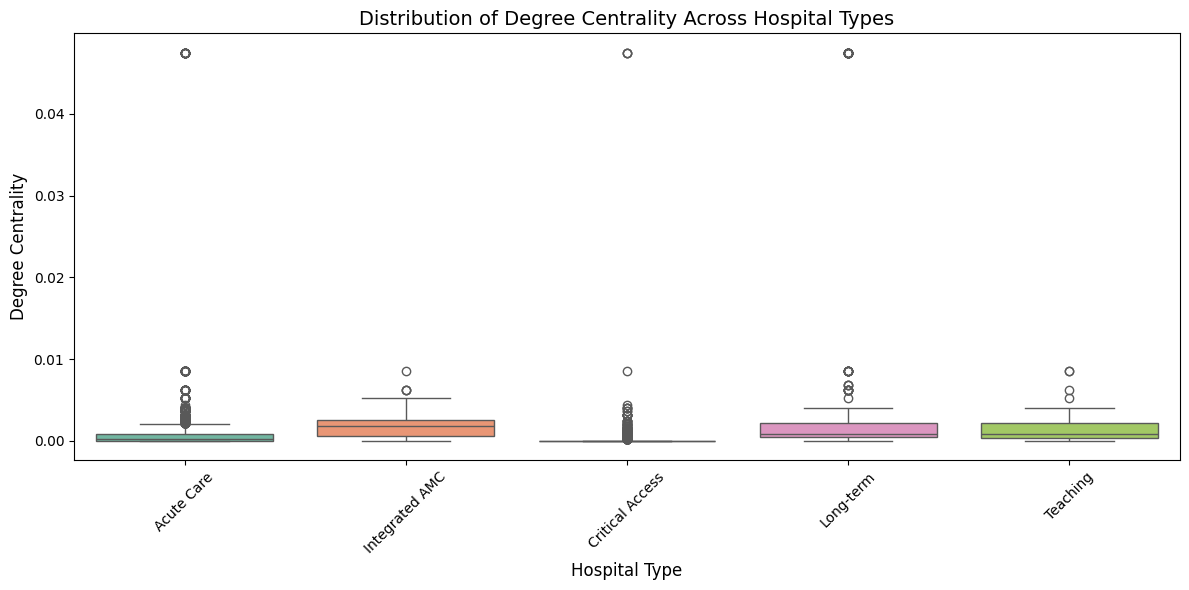

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="HOSPTYPE",
    y="degree_centrality",
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Distribution of Degree Centrality Across Hospital Types", fontsize=14)
plt.xlabel("Hospital Type", fontsize=12)
plt.ylabel("Degree Centrality", fontsize=12)

plt.tight_layout()
plt.show()

According to this visualization, some hospital categories are more connected than others within the network.

**Average Centrality by Hospital Type**

Visualize the average degree centrality of hospital categories to compare them more effectively.

/tmp/ipykernel_2075/2790723281.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2075/2790723281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


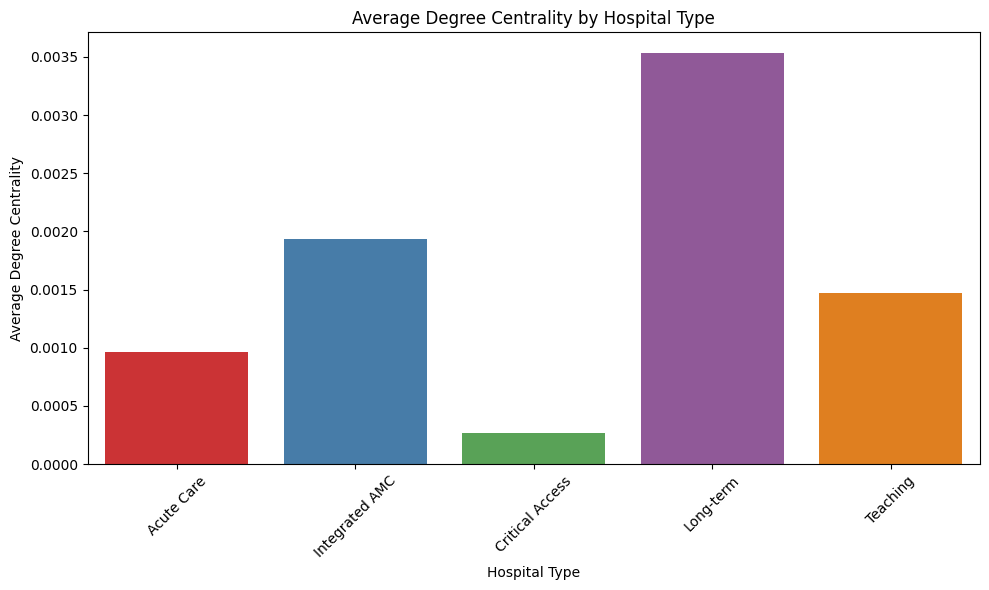

In [15]:
# Most Central Hospital

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="HOSPTYPE",
    y="degree_centrality",
    ci=None,
    palette="Set1"
)

plt.xticks(rotation=45)
plt.title("Average Degree Centrality by Hospital Type")
plt.xlabel("Hospital Type")
plt.ylabel("Average Degree Centrality")

plt.tight_layout()
plt.show()

**Eigenvector Centrality Visualization**

Eigenvector centrality represents both the number of connections a hospital has and the significance of the hospitals to which it is linked.





/tmp/ipykernel_2075/1634150187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


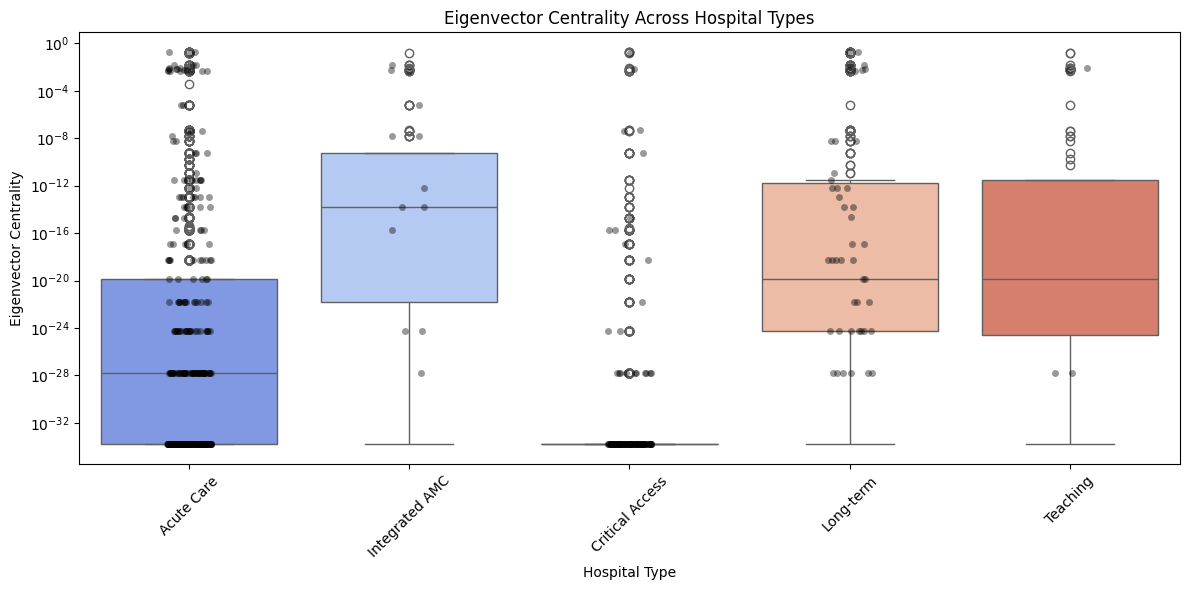

In [16]:
# Eigenvector Centrality Visualization
sample_df = df.sample(500)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="HOSPTYPE",
    y="eigenvector_centrality",
    palette="coolwarm"
)

sns.stripplot(
    data=sample_df,
    x="HOSPTYPE",
    y="eigenvector_centrality",
    color="black",
    alpha=0.4
)

plt.yscale("log")

plt.xticks(rotation=45)

plt.title("Eigenvector Centrality Across Hospital Types")
plt.xlabel("Hospital Type")
plt.ylabel("Eigenvector Centrality")

plt.tight_layout()
plt.show()

**Network Visualization**

Visualize a sample of 200 hospitals to demonstrate the network's structure.



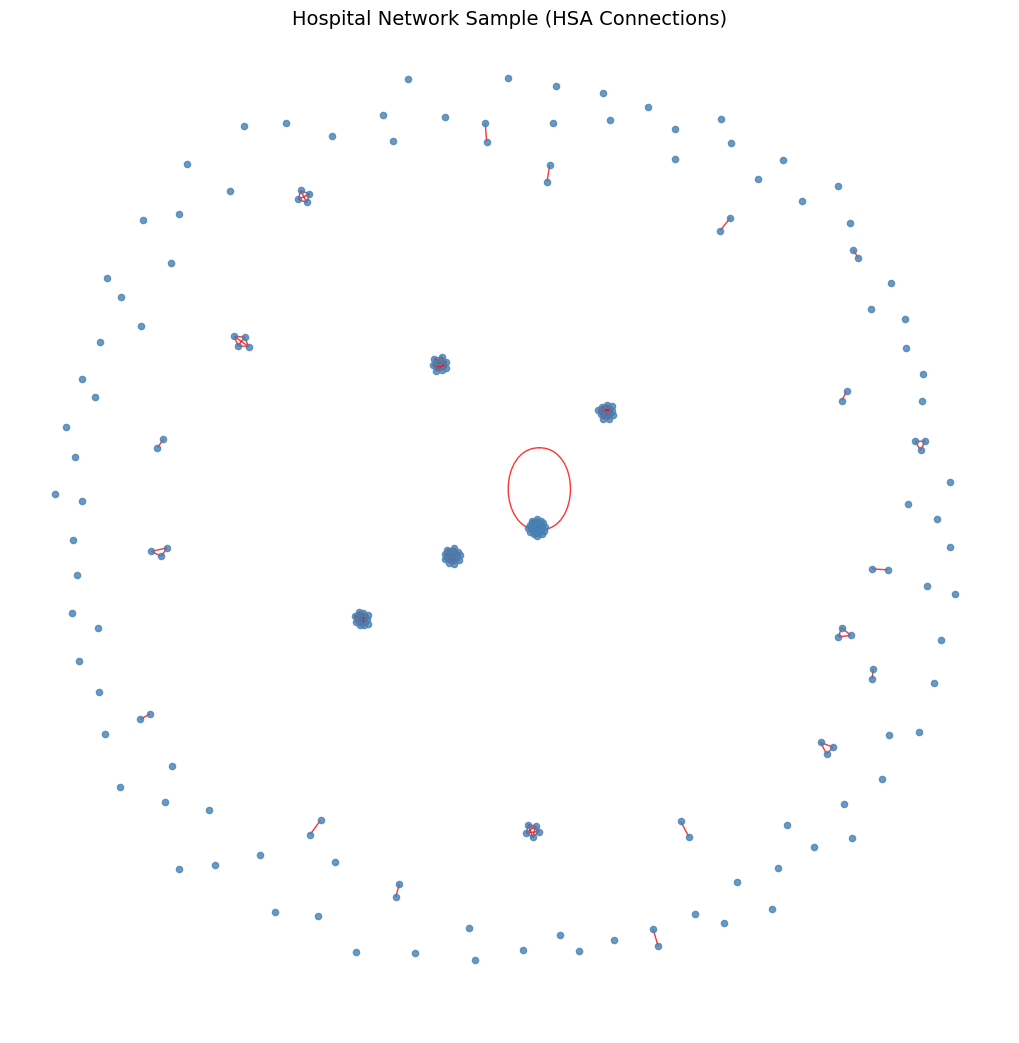

In [17]:
# Network Visualization
plt.figure(figsize=(10,10))

# take a sample so the graph is readable
sub_nodes = list(G.nodes())[:200]
subgraph = G.subgraph(sub_nodes)

# spring layout shows network structure better
pos = nx.spring_layout(subgraph, seed=42)

nx.draw(
    subgraph,
    pos,
    node_size=20,
    node_color="steelblue",
    alpha=0.8,
    edge_color="red",
    with_labels=False
)

plt.title("Hospital Network Sample (HSA Connections)", fontsize=14)
plt.show()


**Nodes**: Hospitals

**Edges**: Hospitals in the same Health Service Area

**Clusters:** hospitals that operate in the same regional healthcare markets.



**Conclusion**

This study used network analysis to investigate the structural characteristics of hospitals in the United States. Hospitals were linked via shared Health Service Areas, resulting in a national hospital network.

Degree and eigenvector centrality were calculated for each hospital and compared to other hospital types. Statistical testing indicated that centrality values vary significantly between hospital types.

The findings indicate that certain hospital types, notably larger or integrated healthcare facilities, may play a more significant role in regional healthcare networks. These hospitals are likely to play major roles in coordinating care, referrals, and healthcare service delivery across respective regions.

Network analysis is a useful tool for analyzing structural relationships within complicated healthcare systems.